In [123]:
# Necessary libraries and useful parameters
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.sparse as sp
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

colors = ["#00274D", "#1B4F72", "#CFA6A6", "#CD5C5C", "#8B3A3A", "#641010"]
blue_red_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_map", colors)

In [124]:
# A 2D contour map of C
def contour_plot(Z, R, C, cmap=blue_red_cmap, cbar_label=r'$c/c_{\mathrm{ref}}$', output_file=None):
    contour = plt.contourf(Z, R, C, levels=200, cmap=cmap, vmax=1)
    cbar = plt.colorbar(contour, label=cbar_label)
    
    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')
    if output_file is not None:
        plt.savefig(output_file, bbox_inches='tight')
    plt.show()

In [125]:
# Model constants
R = 1   # tube radius [m]
L = 1     # tube length [m]
tau = 100 # Characteristic time

# Scaled constants
# D = 2           # diffusion coefficient
# A = 0.2         # electrical advection coefficient
# B = -5          # velocity advection coefficient (B < 0)
# kA, kB = 100, 2 # Langmuir constants


# Scaled constants
E = 10   # electrical advection coefficient
U = 4   # velocity advection coefficient
D = 3    # diffusion coefficient
kA = 20 # Langmuir adsorption constant

domain = ((0, L), (0, R), (0, 1))
M, K = 200, 200
h, ht = 1/M, 1/K

z = np.linspace(domain[0][0], domain[0][1], M+1)
r = np.linspace(domain[1][0], domain[1][1], M+1)
t = np.linspace(domain[2][0], domain[2][1], K+1)

grid = (z, r)
ZZ, RR = np.meshgrid(z, r) 

# Scaled block matrix coefficients
delta = ht/h**2 * D
gamma = delta * (R/(10*L))**2
xi = ht/h * (D-E)/r
vartheta = ht/h * U*(1-r**2)
omega = xi - vartheta - 2*(gamma + delta) - 1

In [126]:
def coeff_matrix(M : int) -> sp.csr_matrix:
    '''
    Create the block tridiagonal matrix A to solve AC^k+1 + g = -C^k.
    Input:
        M: number of grid points
    '''
    Z = M*(M-1)

    ll = np.repeat(delta - xi[1:-1], M)      # Lowest diag
    l = np.repeat(gamma + vartheta[1:-1], M) # Next lowest diag
    d = np.repeat(omega[1:-1], M)            # Main diag 
    u = np.full(Z, gamma)                    # Next highest diag
    uu = np.full(Z, delta)                   # Highest diag
    
    l[M-1::M], u[M-1::M] = 0, 0 # Every M'th element is zero in l and d
    
    A = sp.diags([ll, l, d, u, uu], [-M, -1, 0, 1, M], (Z, Z), format='csr')

    return A

In [127]:
def boundary_vector(grid : tuple, k : int, Ck : np.ndarray, BC : tuple, M : int) -> np.ndarray:
  ''' 
  Create the boundary vector g to solve AC^k+1 + g = -C^k.
  Input:
    grid: (r, z) grids in r- and z directions
       k: the previous iteration step
      Ck: the previous concentration matrix
      BC: (g1, g2, g3) boundary condition functions
       M: number of grid points
  '''
  z, r = grid
  g1, g2, g3 = BC
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M))
  G[::-1, 0] += (gamma+vartheta[1:-1]) * g1(r[1:-1], t[k+1]) # Left contribution
  G[-1, :] += (delta-xi[1]) * g2(z[1:], t[k+1])              # Bottom contribution
  G[0, :] += delta * g3(z[1:], t[k+1])                   # Top contribution

  return G[::-1].ravel() # return G as a vector

In [128]:
def concentration_scheme(grid : tuple, A : np.ndarray, k: int, Ck : np.ndarray, g : np.ndarray, BC : tuple, M : int) -> np.ndarray:
    '''
    Calculate the next concentration matrix C^k+1.
    Input:
        grid: (r, z) grids in r- and z directions
           A: the coefficient matrix
           k: the previous iteration step
          Ck: the previous concentration matrix
           g: the boundary vector
          BC: (g1, g2, g3) boundary condition functions
           M: number of grid points
    '''
    z, r = grid
    g1, g2, g3 = BC
   
    C = np.zeros((M+1, M+1))
    C[::-1, 0] = g1(r, t[k+1]) # Left boundary
    C[-1, :] = g2(z, t[k+1])   # Bottom boundary
    C[0, :] = g3(z, t[k+1])    # Top boundary
   
    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:][::-1].ravel()))
    C[1:-1, 1:] = np.reshape(C_interior, (M-1, M))
   
    return C

In [129]:
# Initial condition
def f(z, r):                   
    return np.zeros_like(ZZ)   
                                                         
# Boundary conditions
def i(r, t): # inlet
    return 1-r**2  

def e(z, t): # electric
    return 0

def d(z, t): # deposition
    return 1 / ((1+np.exp(-t)) * (1+np.exp(-z)))

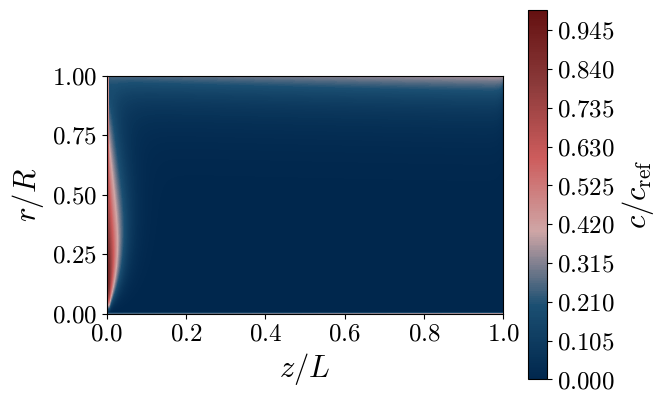

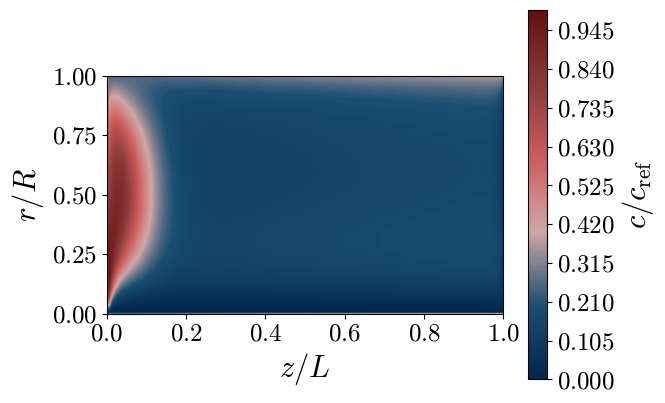

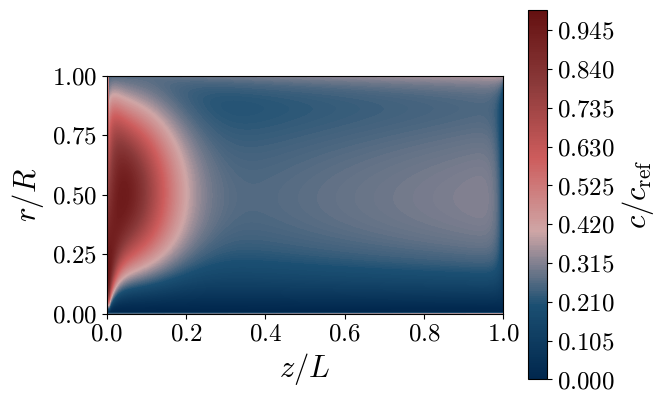

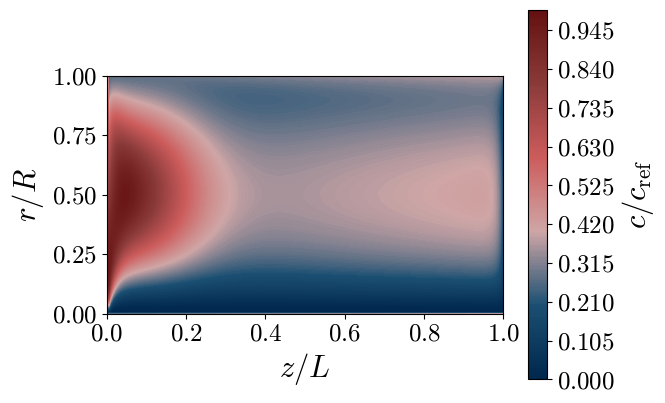

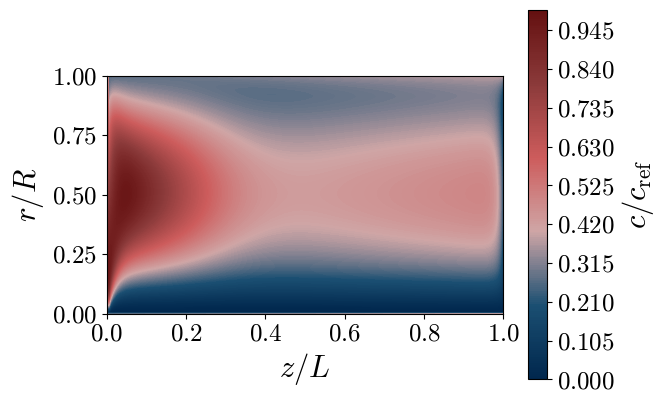

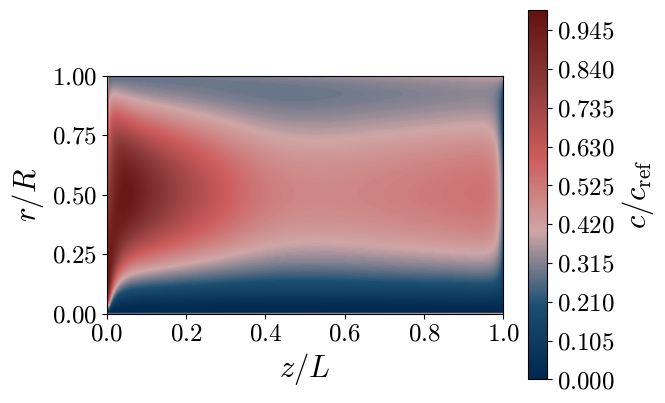

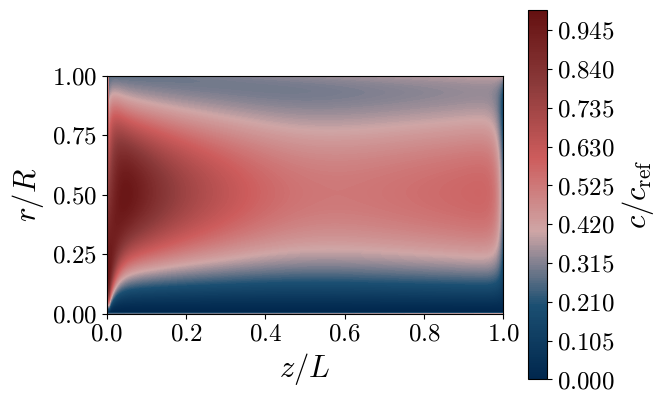

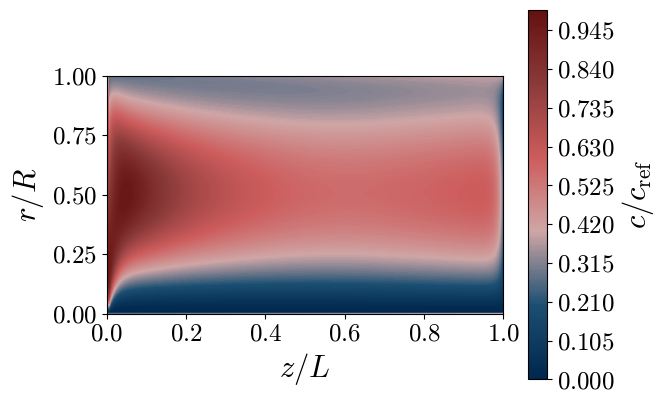

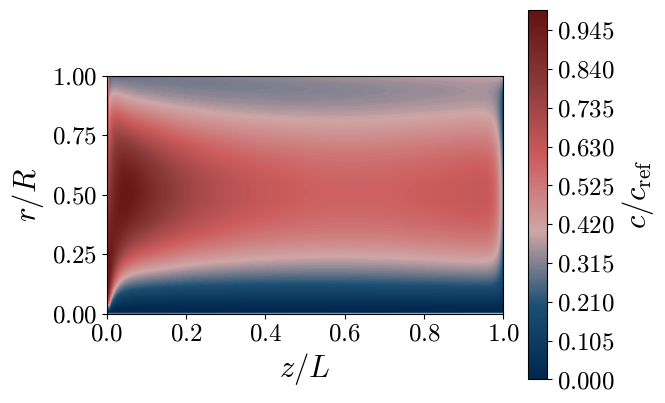

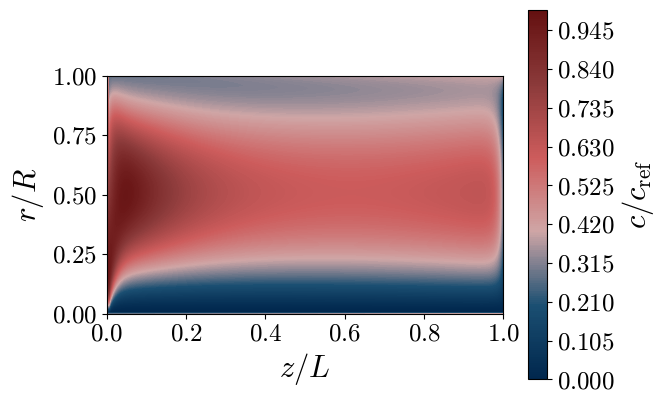

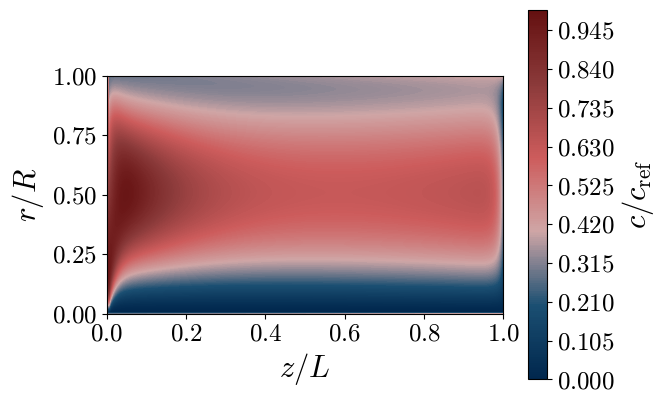

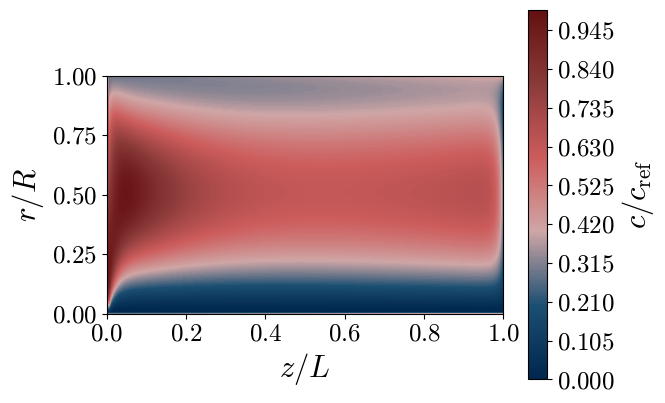

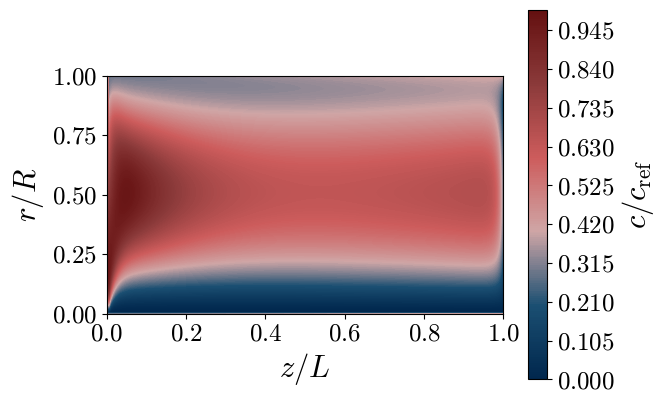

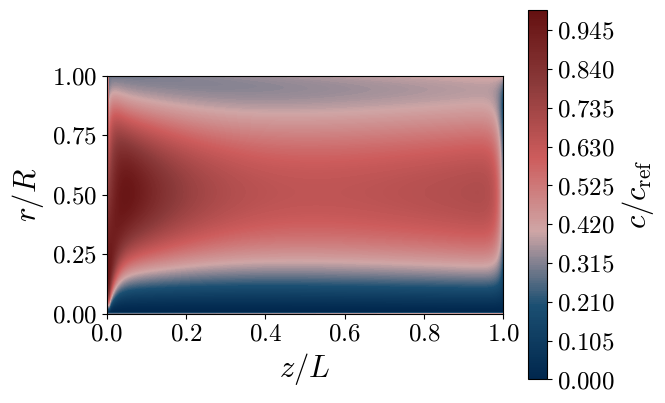

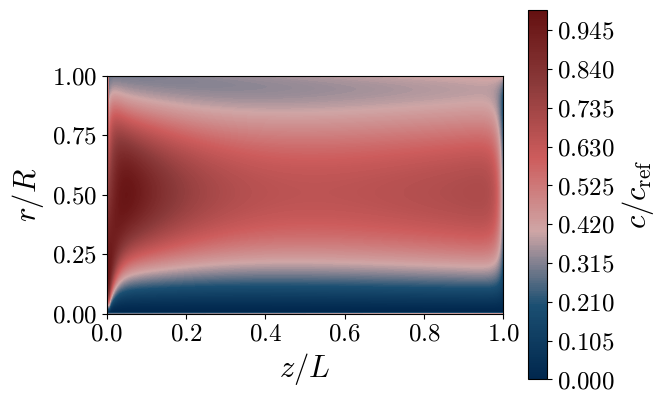

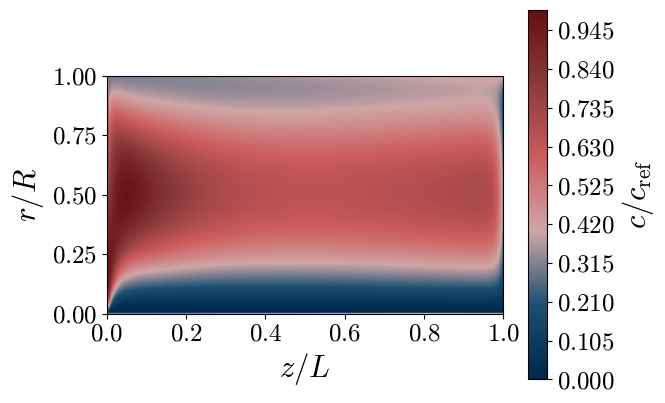

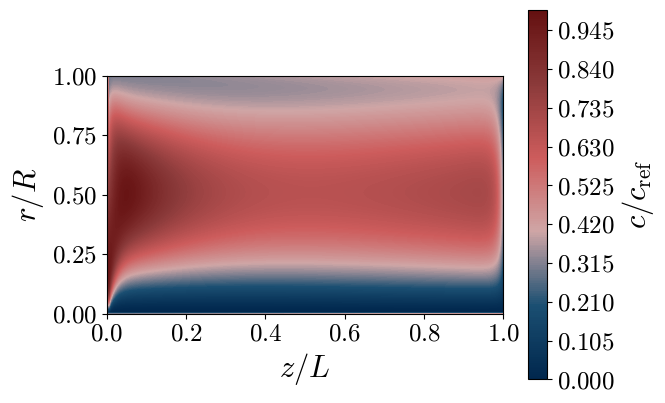

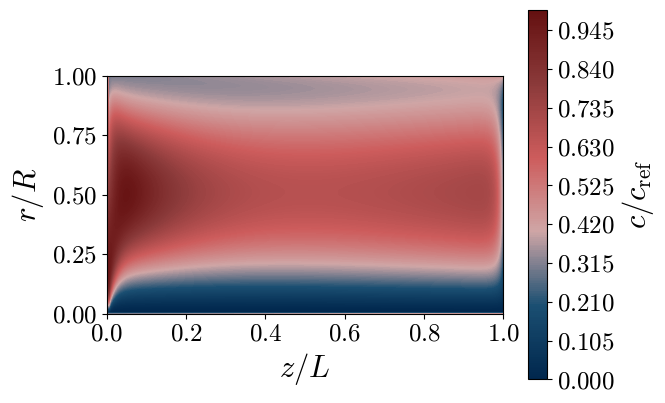

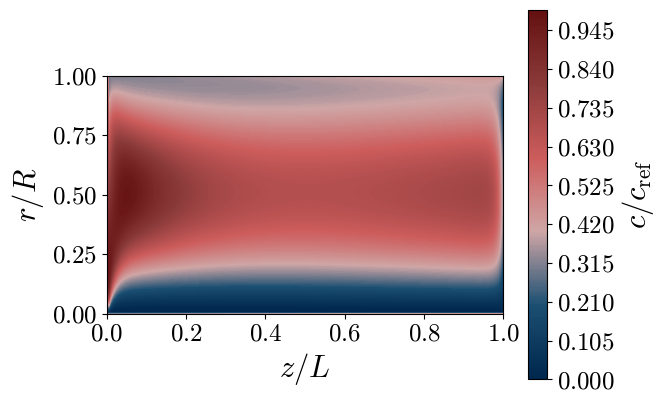

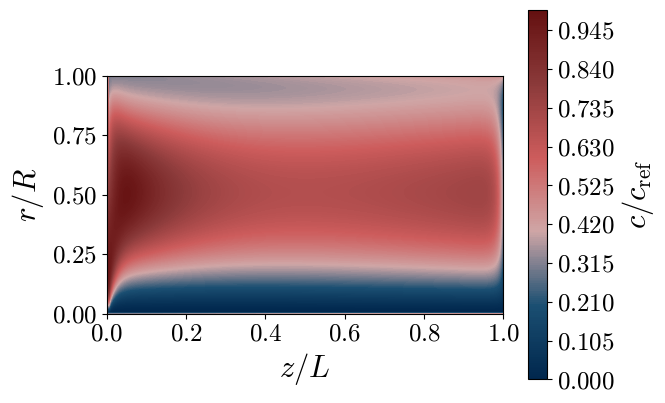

In [131]:
# Example
BC = (i, e, d)
A_matr = coeff_matrix(M)
C0 = f(ZZ, RR) # Initial concentration matrix

Ck = C0
alphanumeric = 65
for k in range(tau):
    g = boundary_vector(grid, k, Ck, BC, M)
    C = concentration_scheme(grid, A_matr, k, Ck, g, BC, M)

    if k%5 == 0:
        plt.figure()
        contour_plot(ZZ, RR, C, output_file=f"output/{chr(alphanumeric)}.png")
        alphanumeric += 1
    Ck = C

In [27]:
from PIL import Image
import glob

img = [] 
frames = [] 
fig = plt.figure()
files = glob.glob("./output/*.png")
files = sorted(files)

images = [Image.open(img).convert('RGB') for img in files]

images[0].save(
    'fds.gif',
    save_all=True,
    append_images=images[1:],
    duration=300,              
    loop=0           
)

<Figure size 640x480 with 0 Axes>

In [132]:
# Example
BC = (i, e, d)
A_matr = coeff_matrix(M)
C0 = f(ZZ, RR) # Initial concentration matrix

Ck = C0
for k in range(tau):
    g = boundary_vector(grid, k, Ck, BC, M)
    C = concentration_scheme(grid, A_matr, k, Ck, g, BC, M)
    if k%5 == 0:
        # print(C[:][-2])
        print(C[0,:])
        # plt.figure()
        # contour_plot(ZZ, RR, C)
    Ck = C

[0.250625   0.25125156 0.25187811 0.25250465 0.25313117 0.25375765
 0.25438409 0.25501049 0.25563683 0.25626311 0.25688932 0.25751545
 0.25814149 0.25876744 0.25939329 0.26001903 0.26064466 0.26127015
 0.26189552 0.26252074 0.26314582 0.26377074 0.26439549 0.26502008
 0.26564448 0.2662687  0.26689272 0.26751654 0.26814015 0.26876354
 0.26938671 0.27000964 0.27063233 0.27125478 0.27187697 0.27249889
 0.27312054 0.27374192 0.274363   0.2749838  0.27560429 0.27622447
 0.27684434 0.27746388 0.27808309 0.27870196 0.27932049 0.27993866
 0.28055647 0.28117391 0.28179097 0.28240765 0.28302394 0.28363983
 0.28425532 0.28487039 0.28548504 0.28609927 0.28671306 0.28732641
 0.28793931 0.28855175 0.28916374 0.28977525 0.29038628 0.29099683
 0.29160689 0.29221644 0.2928255  0.29343404 0.29404206 0.29464955
 0.29525652 0.29586294 0.29646881 0.29707413 0.29767889 0.29828308
 0.2988867  0.29948974 0.30009219 0.30069404 0.3012953  0.30189594
 0.30249598 0.30309539 0.30369417 0.30429233 0.30488984 0.3054